In [2]:
import pandas as pd
import numpy as np

# Load the DataFrame
df = pd.read_csv("remaining_genomes.csv", index_col=0, dtype=str)

# Determine the number of rows per split
num_splits = 5
split_size = int(np.ceil(len(df) / num_splits))

# Split the DataFrame into 5 separate DataFrames
df1, df2, df3, df4, df5 = [df.iloc[i * split_size:(i + 1) * split_size] for i in range(num_splits)]

# Print number of rows in each split
print(f"df1: {len(df1)} rows")
print(f"df2: {len(df2)} rows")
print(f"df3: {len(df3)} rows")
print(f"df4: {len(df4)} rows")
print(f"df5: {len(df5)} rows")


df1: 48890 rows
df2: 48890 rows
df3: 48890 rows
df4: 48890 rows
df5: 48887 rows


In [3]:
df5 = df5.drop(columns=["Unnamed: 0"])


In [4]:
df5.to_csv("genomes.csv")

In [5]:
import pandas as pd

# Example DataFrame

# 1. Filter rows where contigs_patric and contig_count are the same
same_df = df[df['contigs_patric'] == df['contig_count']]

# 2. Filter rows where contigs_patric and contig_count are not the same
not_same_df = df[df['contigs_patric'] != df['contig_count']]

# 3. Count occurrences of each number where both are the same
same_counts = same_df['contigs_patric'].value_counts().reset_index(name='count')
same_counts.columns = ['value', 'same_count']

# 4. Count how many rows where contigs_patric and contig_count are not the same
not_same_count = not_same_df.shape[0]

# 5. Combine the results into one table using pd.concat
not_same_df = pd.DataFrame([{'value': 'Not Same', 'same_count': not_same_count}])
summary = pd.concat([same_counts, not_same_df], ignore_index=True)

# 6. Display the summary
summary.to_csv('summary.csv',index=False)


In [6]:
df2

,Unnamed: 0,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
53201,56391,139,S06_Assembly,139.470,173,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,173
53202,56392,139,S07_Assembly,139.463,250,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,250
53203,56393,139,S08_Assembly,139.465,74,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,74
53204,56394,139,S09_Assembly,139.462,50,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,50
53205,56395,139,S10_Assembly,139.466,49,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,49
...,...,...,...,...,...,...,...
108651,116686,208223,PF-9,208223.23,25,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,25
108655,116691,208224,11778,208224.165,21,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,21
108657,116693,208224,120067,208224.175,64,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,64
108658,116694,208224,120081,208224.177,58,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,58


In [7]:
import pandas as pd

# Assuming df is your DataFrame
# Create boolean conditions for each of the two scenarios
condition_1 = df['contigs_patric']!=df['contig_count'] 


# Combine both conditions using the logical OR operator
filtered_df = df[condition_1]

# Display the filtered DataFrame
filtered_df


,Unnamed: 0,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
8,8,1000565,FAM5,1000565.3,60,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,58
13,13,1000570,DSM 20563,1000570.8,14,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,16
20,20,1000952,HC-17A2,1000952.3,136,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,135
27,30,1001586,Mallika,1001586.3,335,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,41
28,31,1001588,2002000621,1001588.3,220,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,71
...,...,...,...,...,...,...,...
273916,295024,999430,ATCC 35404,999430.5,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,33
273917,295025,999431,H1-T,999431.4,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,26
273918,295026,999432,H-22,999432.5,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,21
273920,295028,999434,OTK,999434.4,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,11


In [8]:
filtered_df.to_csv("10k_diff.csv")

In [9]:
import pandas as pd

# Assuming df2 is your DataFrame
# Ensure contig_count is an integer
df2['contig_count'] = df2['contig_count'].astype(int)

# Create condition for genomes with exactly 4 contigs
condition_4 = df2['contig_count'] == 4

# Filter the DataFrame based on the condition
filtered_4_df = df2[condition_4]

# Display the filtered DataFrame (optional)
print(filtered_4_df)

# Count how many genomes meet the condition (contig_count == 4)
num_genomes_4 = filtered_4_df.shape[0]

# Display the count
print(f'Number of genomes with exactly 4 contigs: {num_genomes_4}')


       Unnamed: 0 taxon_id       strain   genome_id contigs_patric  \
53875       57153  1392488     Hel_I_48   1392488.5              5   
54025       57320     1396           3a   1396.1856              1   
54048       57343     1396           A1    1396.418             58   
54671       57976     1396       HD1.4B   1396.2639             53   
54672       57977     1396        HD2.4   1396.2636             48   
...           ...      ...          ...         ...            ...   
100293     107363   192955      SSSE-03  192955.851              4   
100324     107405     1930      B21-094    1930.167              4   
101849     109056  1954351  APEC O2-211   1954351.6              1   
105905     113635  2015315         SS07   2015315.3              3   
106737     114505  2026657      DRC1506   2026657.5              1   

                                                 ftp_path  contig_count  
53875   https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...             4  
54025   htt

/var/folders/6d/tssj4xrn099f31yn8bqdpsgwsqb764/T/ipykernel_10855/589382892.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['contig_count'] = df2['contig_count'].astype(int)


In [10]:
import pandas as pd

# Assuming df is your DataFrame
# Create boolean conditions for each of the two scenarios
condition_1 = (df['contigs_patric'] == '1') & (df['contig_count'] == '2')
condition_2 = (df['contigs_patric'] == '2') & (df['contig_count'] == '1')

# Combine both conditions using the logical OR operator
filtered_df = df[condition_1 | condition_2]

# Display the filtered DataFrame
filtered_df

,Unnamed: 0,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
135,147,1004786,AltDE1,1004786.12,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
136,148,1004787,Balearic Sea AD45,1004787.19,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
327,346,1006155,WS 4560,1006155.9,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1
398,429,1009856,USDA,1009856.5,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
399,430,1009857,W106,1009857.5,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
...,...,...,...,...,...,...,...
270734,291499,907237,Lithuania75,907237.6,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
271029,291820,91891,Lorraine,91891.50,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
272549,293502,96345,160401-1/5N,96345.197,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
272739,293731,96901,BG33R,96901.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2


In [11]:
import pandas as pd

# Assuming df is your DataFrame
filtered_df = df[df['contigs_patric'] != df['contig_count']]

# Display the filtered DataFrame
print(filtered_df)


       Unnamed: 0 taxon_id          strain  genome_id contigs_patric  \
8               8  1000565            FAM5  1000565.3             60   
13             13  1000570       DSM 20563  1000570.8             14   
20             20  1000952         HC-17A2  1000952.3            136   
27             30  1001586         Mallika  1001586.3            335   
28             31  1001588      2002000621  1001588.3            220   
...           ...      ...             ...        ...            ...   
273916     295024   999430      ATCC 35404   999430.5              1   
273917     295025   999431            H1-T   999431.4              1   
273918     295026   999432            H-22   999432.5              1   
273920     295028   999434             OTK   999434.4              1   
273936     295044   999552  DSM 14336; MB2  999552.18              1   

                                                 ftp_path contig_count  
8       https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...     

In [12]:
import pandas as pd

df = pd.read_csv('results/2_multiple_xml_filenames.csv', on_bad_lines='skip')  # Skip rows with too many fields
df.head(5).to_csv("genomes.csv")


In [13]:
import pandas as pd
patric = pd.read_csv("genome_metadata", sep='\t',dtype=str)
patric[patric['genome_id']=='1006.10']['genome_length']

471346    4535079
Name: genome_length, dtype: object

In [14]:
Total 8844. The percentage for 7963 is approximately 90.04%, and the percentage for 881 is approximately 9.96%

SyntaxError: invalid syntax (2847123409.py, line 1)

In [ ]:
import pandas as pd

df = pd.read_csv("results/2to2results.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Perform the comparison
condition = df['n_of_1'] == df['subject_length']
df_matched = df[condition]

df_matched


,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_-1,n_of_0,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename
0,22,1001240,DSM 21065,1001240.6,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1001240.6.fna,GCF_014200405.1_ASM1420040v1_genomic.fna,4531652,...,0,0,4531652,0,0,0,0,0,0,1001240_subject_array_1738727576.bin
1,27,1001582,LL3,1001582.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1001582.3.fna,GCF_000204275.1_ASM20427v1_genomic.fna,4001985,...,0,0,4001985,0,0,0,0,0,0,1001582_subject_array_1738727578.bin
2,40,1001705,1S-152-0914,1001705.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1001705.3.fna,GCF_000271285.1_ASM27128v1_genomic.fna,4897666,...,0,0,4897666,0,0,0,0,0,0,1001705_subject_array_1738727579.bin
3,91,100225,LK16-18,100225.4,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,100225.4.fna,GCF_003391095.1_ASM339109v1_genomic.fna,3631970,...,0,0,3631970,0,0,0,0,0,0,100225_subject_array_1738727581.bin
4,106,1002795,MB620,1002795.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1002795.3.fna,GCF_015732155.1_ASM1573215v1_genomic.fna,2691682,...,0,0,2691682,0,0,0,0,0,0,1002795_subject_array_1738727582.bin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8839,294847,996558,FSL M8-0129,996558.21,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,996558.21.fna,GCF_038039325.1_ASM3803932v1_genomic.fna,4138431,...,0,0,4138431,0,0,0,0,0,0,996558_subject_array_1738743379.bin
8840,294850,996558,FSL W8-1055,996558.24,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,996558.24.fna,GCF_039409915.1_ASM3940991v1_genomic.fna,4047303,...,0,0,4047303,0,0,0,0,0,0,996558_subject_array_1738743381.bin
8841,294991,998674,DSM 2157,998674.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,998674.3.fna,GCF_000419525.1_ASM41952v1_genomic.fna,5185674,...,0,0,5185674,0,0,0,0,0,0,998674_subject_array_1738743383.bin
8842,295053,999931,39T,999931.5,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,2,999931.5.fna,GCF_910573815.1_Bh_39T_genomic.fna,3622728,...,0,0,3622728,0,0,0,0,0,0,999931_subject_array_1738743384.bin


In [ ]:
import pandas as pd

df = pd.read_csv("results/2to2results.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Create matched and unmatched DataFrames
matched_df = df[df['n_of_1'] == df['subject_length']]
unmatched_df = df[df['n_of_1'] != df['subject_length']]


unmatched_df


,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_-1,n_of_0,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename
5,107,1002804,CIII-1,1002804.6,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1002804.6.fna,GCF_000237285.1_ASM23728v1_genomic.fna,1807534,...,0,9154,1798380,0,0,0,0,0,0,1002804_subject_array_1738727583.bin
12,319,1005665,FY-07,1005665.11,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1005665.11.fna,GCF_027886705.1_ASM2788670v1_genomic.fna,13963,...,0,5118956,13963,0,0,0,0,0,0,1005665_subject_array_1738727598.bin
30,887,102886,LBVP101/21,102886.11,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,102886.11.fna,GCF_030848225.1_ASM3084822v1_genomic.fna,1983925,...,0,183,1983742,0,0,0,0,0,0,102886_subject_array_1738727626.bin
35,967,1032070,LMG 9904,1032070.5,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1032070.5.fna,GCF_006165035.1_ASM616503v1_genomic.fna,2107083,...,0,2008,2105075,0,0,0,0,0,0,1032070_subject_array_1738727631.bin
56,1286,1038922,Q2-87,1038922.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1038922.3.fna,GCF_000281895.1_ASM28189v1_genomic.fna,6367968,...,0,170,5,0,0,2,6367991,0,0,1038922_subject_array_1738727704.bin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8781,292500,940139,03SUJ4,940139.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,940139.3.fna,GCF_046263735.1_ASM4626373v1_genomic.fna,4163374,...,0,80313,1140,0,0,1,4163240,0,5,940139_subject_array_1738743281.bin
8788,292622,94138,DRD-90,94138.32,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,94138.32.fna,GCF_030970965.1_ASM3097096v1_genomic.fna,2533843,...,0,1700,2532143,0,0,0,0,0,0,94138_subject_array_1738743293.bin
8789,292674,943346,KB1,943346.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,943346.3.fna,GCF_007830295.1_ASM783029v1_genomic.fna,6057612,...,1,2855,6054667,0,2,32,55,0,0,943346_subject_array_1738743295.bin
8795,293179,95486,FDAARGOS_720,95486.464,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,95486.464.fna,GCF_012273415.1_ASM1227341v1_genomic.fna,7247662,...,0,199,7247463,0,0,0,0,0,0,95486_subject_array_1738743305.bin


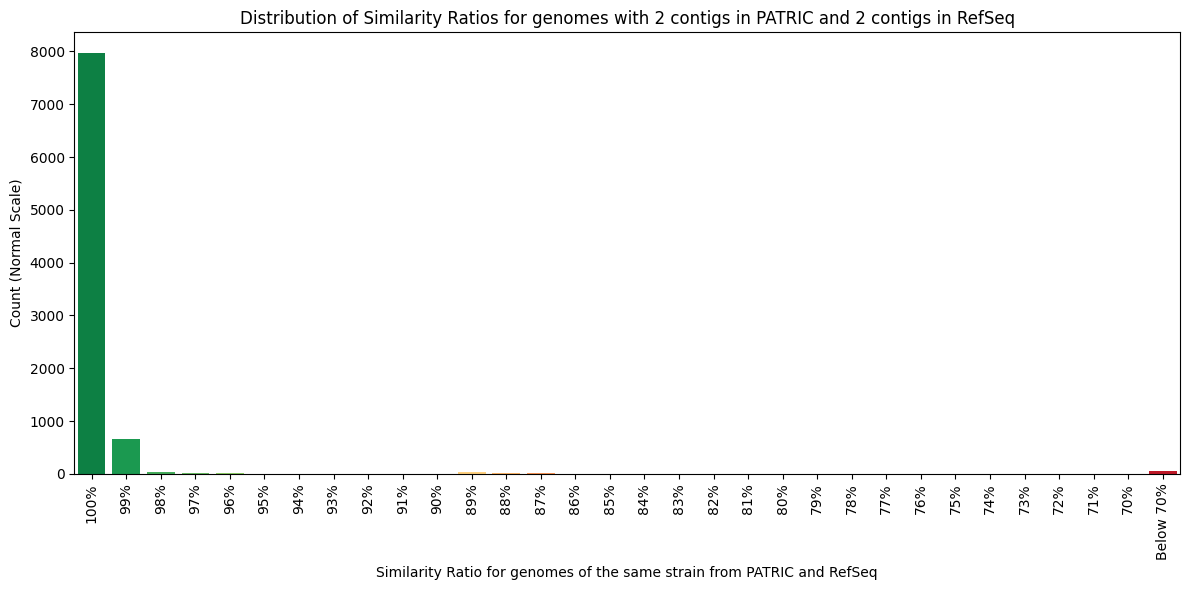

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read the CSV
df = pd.read_csv("results/2to2results.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Compute ratio
df['ratio'] = df['n_of_1'] / df['subject_length']

# Define a function to categorize the ratios
def categorize_ratio(ratio):
    if ratio == 1.0:
        return '100%'  # Change from '1.0' to '100%'
    elif 0.99 < ratio < 1.0:
        return '99%'
    elif 0.98 < ratio < 0.99:
        return '98%'
    elif 0.97 < ratio < 0.98:
        return '97%'
    elif 0.96 < ratio < 0.97:
        return '96%'
    elif 0.95 < ratio < 0.96:
        return '95%'
    elif 0.94 < ratio < 0.95:
        return '94%'
    elif 0.93 < ratio < 0.94:
        return '93%'
    elif 0.92 < ratio < 0.93:
        return '92%'
    elif 0.91 < ratio < 0.92:
        return '91%'
    elif 0.9 < ratio < 0.91:
        return '90%'
    elif 0.89 < ratio < 0.90:
        return '89%'
    elif 0.88 < ratio < 0.89:
        return '88%'
    elif 0.87 < ratio < 0.88:
        return '87%'
    elif 0.86 < ratio < 0.87:
        return '86%'
    elif 0.85 < ratio < 0.86:
        return '85%'
    elif 0.84 < ratio < 0.85:
        return '84%'
    elif 0.83 < ratio < 0.84:
        return '83%'
    elif 0.82 < ratio < 0.83:
        return '82%'
    elif 0.81 < ratio < 0.82:
        return '81%'
    elif 0.8 < ratio < 0.81:
        return '80%'
    elif 0.79 < ratio < 0.80:
        return '79%'
    elif 0.78 < ratio < 0.79:
        return '78%'
    elif 0.77 < ratio < 0.78:
        return '77%'
    elif 0.76 < ratio < 0.77:
        return '76%'
    elif 0.75 < ratio < 0.76:
        return '75%'
    elif 0.74 < ratio < 0.75:
        return '74%'
    elif 0.73 < ratio < 0.74:
        return '73%'
    elif 0.72 < ratio < 0.73:
        return '72%'
    elif 0.71 < ratio < 0.72:
        return '71%'
    elif 0.7 < ratio < 0.71:
        return '70%'
    else:
        return 'Below 70%'

# Apply the categorization
df['ratio_category'] = df['ratio'].apply(categorize_ratio)

# Count occurrences per category
category_counts = df['ratio_category'].value_counts()

# Define a custom color palette
custom_palette = sns.color_palette("RdYlGn_r", n_colors=len(category_counts))

# Plot the data with Seaborn countplot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='ratio_category', data=df, order=[
    '100%', '99%', '98%', '97%', '96%', '95%', '94%', 
    '93%', '92%', '91%', '90%', '89%', '88%', 
    '87%', '86%', '85%', '84%', '83%', '82%', 
    '81%', '80%', '79%', '78%', '77%', '76%', 
    '75%', '74%', '73%', '72%', '71%', '70%', 
    'Below 70%'
])

# Apply the custom palette to the bars
for p, color in zip(ax.patches, custom_palette):
    p.set_facecolor(color)

# Customize the plot
plt.xticks(rotation=90)
plt.xlabel('Similarity Ratio for genomes of the same strain from PATRIC and RefSeq')
plt.ylabel('Count (Normal Scale)')
plt.title('Distribution of Similarity Ratios for genomes with 2 contigs in PATRIC and 2 contigs in RefSeq')
#plt.yscale('log')
plt.tight_layout()
plt.show()


In [ ]:
l = list(df[df['ratio']<0.1]['col6'])

In [ ]:
df[df['ratio']<0.1]

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename,ratio,ratio_category
157,10694,1185653,DSM 14505,1185653.6,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,1185653.6.fna,GCF_001687565.2_ASM168756v2_genomic.fna,3830056,...,39079,0,0,0,3765502,0,12,1185653_subject_array_1738943179.bin,0.010271,Below 10%
256,15509,1271864,CFSAN002069,1271864.3,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,1271864.3.fna,GCF_000430085.2_ASM43008v2_genomic.fna,4932086,...,536,0,0,10,4931360,0,10,1271864_subject_array_1738943327.bin,0.000109,Below 10%
283,17184,1280,5118.N,46170.244,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,46170.244.fna,GCF_001717645.1_ASM171764v3_genomic.fna,3012759,...,2041,0,15,282,2925030,0,685,46170_subject_array_1738943356.bin,0.000697,Below 10%
432,24650,1280,TUM22702,1280.53238,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,1280.53238.fna,GCF_040931745.1_ASM4093174v1_genomic.fna,2976734,...,0,0,0,154,2978522,0,20,1280_subject_array_1738943515.bin,0.000000,Below 10%
741,51652,1352,K189-3,1352.15661,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,1352.15661.fna,GCF_028335605.1_ASM2833560v1_genomic.fna,197358,...,234542,0,7,1515,43842,0,51,1352_subject_array_1738943883.bin,0.082726,Below 10%
745,51676,1352,K75-1,1352.15662,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,1352.15662.fna,GCF_028335565.1_ASM2833556v1_genomic.fna,197358,...,237627,0,27,1505,41831,0,34,1352_subject_array_1738943887.bin,0.083750,Below 10%
1251,77083,152480,CEP0996,152480.137,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,152480.137.fna,GCF_026683835.2_ASM2668383v2_genomic.fna,7391553,...,24,0,0,723,7383597,0,57,152480_subject_array_1738944744.bin,0.000003,Below 10%
1451,84417,1612,K68-8,1612.66,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,1612.66.fna,GCF_028335385.1_ASM2833538v1_genomic.fna,1814,...,1814,0,0,0,0,0,0,1612_subject_array_1738945046.bin,0.000719,Below 10%
1671,103493,1812935,WCHER090065,1812935.43,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,1812935.43.fna,GCF_009184765.2_ASM918476v2_genomic.fna,4943979,...,82723,0,1,3,4872196,0,0,1812935_subject_array_1738945407.bin,0.016695,Below 10%
1776,108462,195,CFSAN032805,195.1176,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,195.1176.fna,GCF_009649055.1_ASM964905v1_genomic.fna,1750173,...,80168,0,1,23,1669982,0,3,195_subject_array_1738945619.bin,0.045806,Below 10%


In [ ]:
l

['https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/001/687/565/GCF_001687565.2_ASM168756v2',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/430/085/GCF_000430085.2_ASM43008v2',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/001/717/645/GCF_001717645.1_ASM171764v3',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/040/931/745/GCF_040931745.1_ASM4093174v1',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/028/335/605/GCF_028335605.1_ASM2833560v1',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/028/335/565/GCF_028335565.1_ASM2833556v1',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/026/683/835/GCF_026683835.2_ASM2668383v2',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/028/335/385/GCF_028335385.1_ASM2833538v1',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/009/184/765/GCF_009184765.2_ASM918476v2',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/009/649/055/GCF_009649055.1_ASM964905v1',
 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/812/205/GCF_000812205.2_ASM81220v2',
 'https://ftp.ncbi

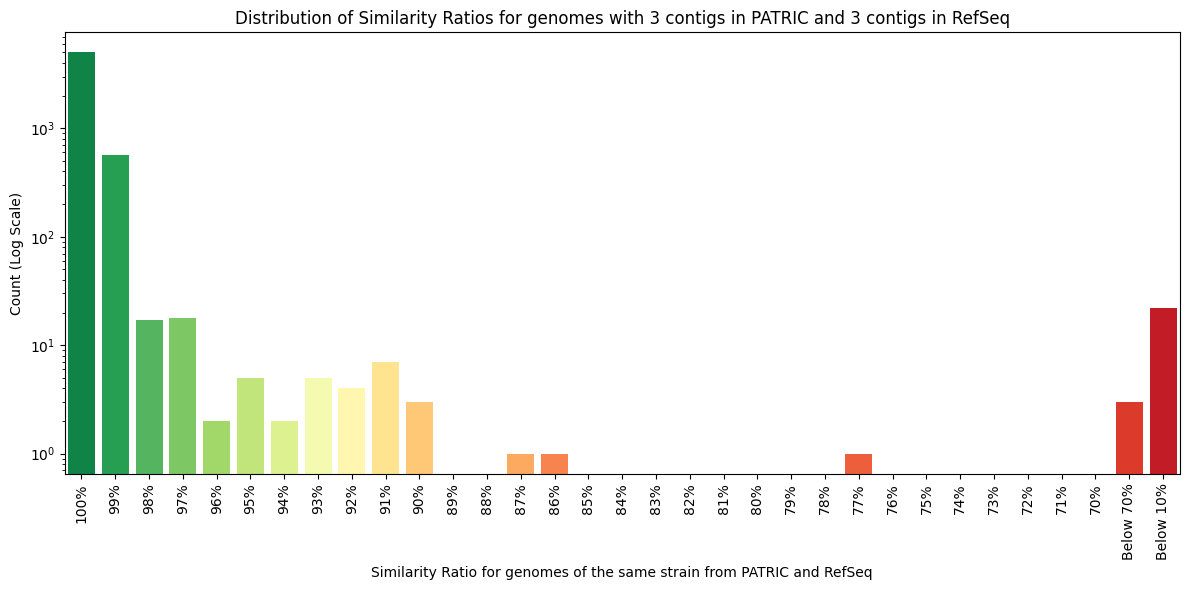

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV
df = pd.read_csv("results/output_file.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Compute ratio
df['ratio'] = df['n_of_1'] / df['subject_length']

# Define a function to categorize the ratios
def categorize_ratio(ratio):
    if ratio < 0.1:
        return 'Below 10%'
    elif ratio < 0.7:
        return 'Below 70%'
    elif ratio == 1.0:
        return '100%'
    else:
        return f"{int(ratio * 100)}%"

# Apply the categorization
df['ratio_category'] = df['ratio'].apply(categorize_ratio)

# Count occurrences per category
category_counts = df['ratio_category'].value_counts()

# Define a custom color palette
custom_palette = sns.color_palette("RdYlGn_r", n_colors=len(category_counts))

# Define the order for the bars (placing "Less than 10%" last)
category_order = [f"{i}%" for i in range(100, 69, -1)] + ['Below 70%', 'Below 10%']

# Plot the data with Seaborn countplot
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    x='ratio_category', 
    data=df, 
    order=category_order
)

# Apply the custom palette to the bars
for p, color in zip(ax.patches, custom_palette):
    p.set_facecolor(color)

# Customize the plot
plt.xticks(rotation=90)
plt.xlabel('Similarity Ratio for genomes of the same strain from PATRIC and RefSeq')
plt.ylabel('Count (Log Scale)')
plt.title('Distribution of Similarity Ratios for genomes with 3 contigs in PATRIC and 3 contigs in RefSeq')
plt.yscale('log')
plt.tight_layout()
plt.show()


In [ ]:
df

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename,ratio,ratio_category
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,1868316,0,25,53,24129,0,0,1001534_subject_array_1739113446.bin,0.987035,98%
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,1968488,0,23,52,29,0,0,1001542_subject_array_1739113448.bin,0.999938,99%
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,5434353,0,0,0,0,0,0,1001585_subject_array_1739113452.bin,1.000000,100%
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,8667664,0,0,0,0,0,0,100226_subject_array_1739113458.bin,1.000000,100%
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,1284727,0,0,0,0,0,0,1002672_subject_array_1739113459.bin,1.000000,100%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20646,294973,99822,DB60705-15,99822.28,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.28.fna,GCF_009650275.1_ASM965027v1_genomic.fna,2190656,...,2190557,0,0,0,0,0,0,99822_subject_array_1739184665.bin,0.999955,99%
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,2201894,0,0,0,0,0,0,99822_subject_array_1739184667.bin,1.000000,100%
20648,294989,99822,STREP97-15,99822.29,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.29.fna,GCF_009650295.1_ASM965029v1_genomic.fna,2432570,...,2432471,0,0,0,0,0,0,99822_subject_array_1739184669.bin,0.999959,99%
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,1873758,0,0,0,0,0,0,999183_subject_array_1739184670.bin,1.000000,100%


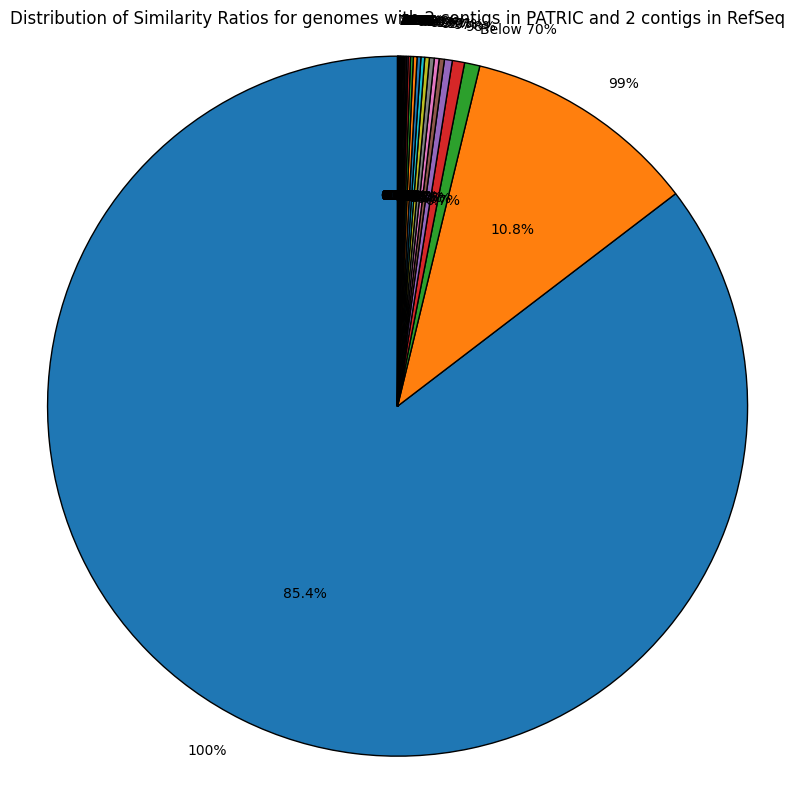

In [ ]:
# Plot the pie chart with percentages in the labels
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, 
        startangle=90, wedgeprops={'edgecolor': 'black'}, 
        autopct='%1.1f%%')  # Show percentage labels
plt.title('Distribution of Similarity Ratios for genomes with 2 contigs in PATRIC and 2 contigs in RefSeq')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.
plt.tight_layout()
plt.show()


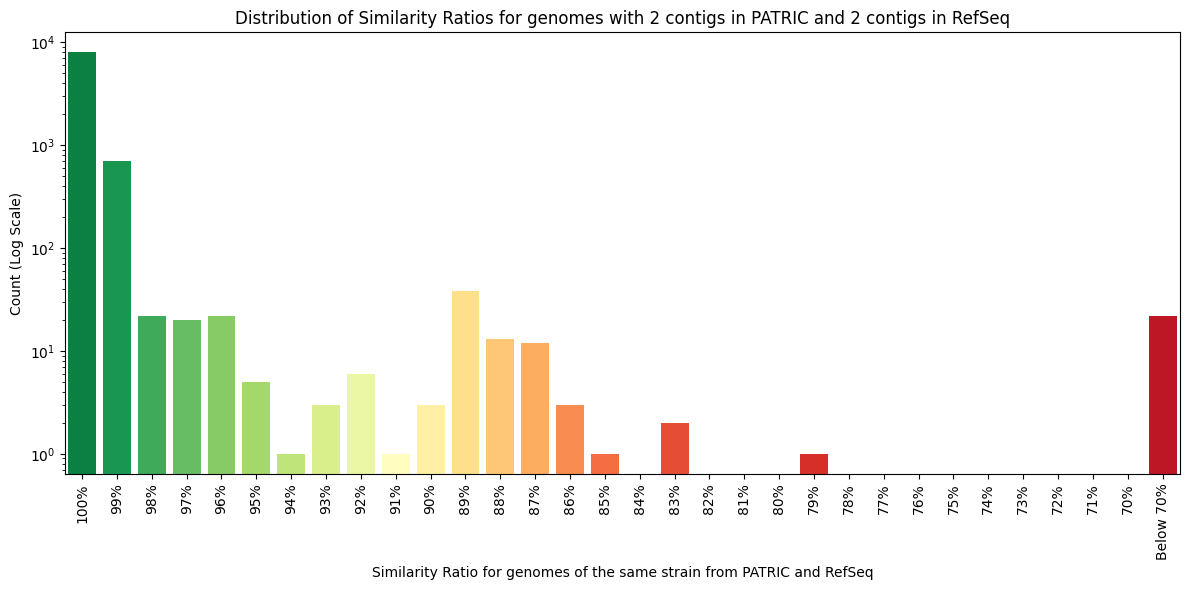

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read the CSV
df = pd.read_csv("results/2to2results.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['n_of_5'] = pd.to_numeric(df['n_of_5'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Sum up n_of_1 and n_of_5
df['n_total'] = df['n_of_1'].fillna(0) + df['n_of_5'].fillna(0)

# Compute ratio
df['ratio'] = df['n_total'] / df['subject_length']

# Define a function to categorize the ratios
def categorize_ratio(ratio):
    if ratio == 1.0:
        return '100%'
    for i in range(99, 69, -1):  # Categorizing from 99% to 70%
        if (i / 100) < ratio <= ((i + 1) / 100):
            return f'{i}%'
    return 'Below 70%'

# Apply the categorization
df['ratio_category'] = df['ratio'].apply(categorize_ratio)

# Count occurrences per category
category_counts = df['ratio_category'].value_counts()

# Define a custom color palette
custom_palette = sns.color_palette("RdYlGn_r", n_colors=len(category_counts))

# Plot the data with Seaborn countplot
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    x='ratio_category', 
    data=df, 
    order=[f'{i}%' for i in range(100, 69, -1)] + ['Below 70%']
)

# Apply the custom palette to the bars
for p, color in zip(ax.patches, custom_palette):
    p.set_facecolor(color)

# Customize the plot
plt.xticks(rotation=90)
plt.xlabel('Similarity Ratio for genomes of the same strain from PATRIC and RefSeq')
plt.ylabel('Count (Log Scale)')
plt.title('Distribution of Similarity Ratios for genomes with 2 contigs in PATRIC and 2 contigs in RefSeq')
plt.yscale('log')
plt.tight_layout()
plt.show()


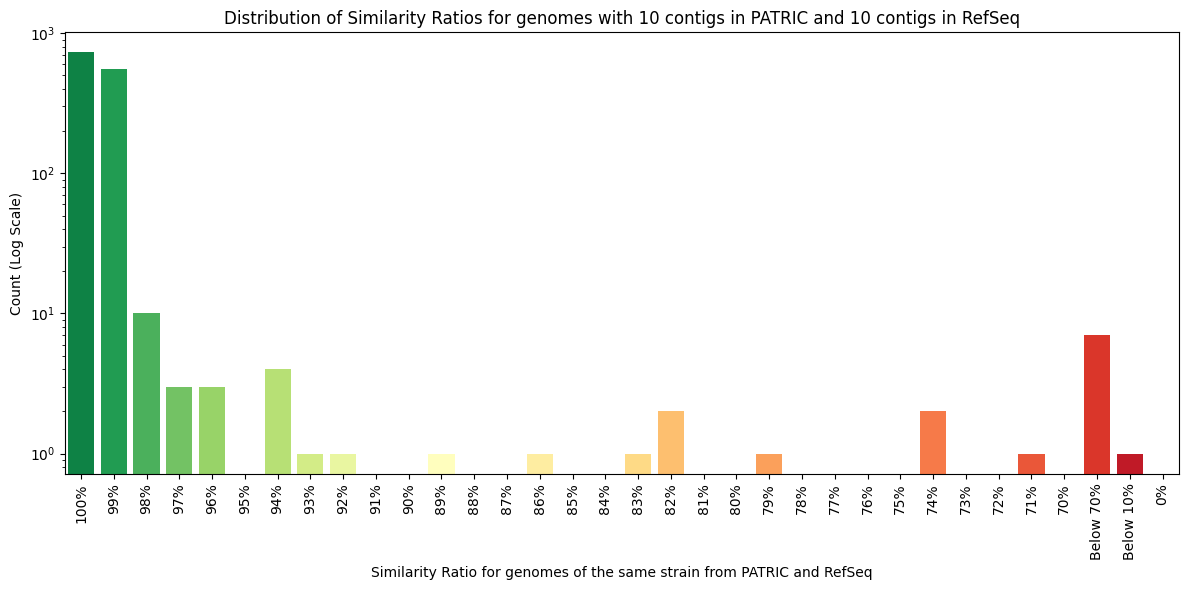

In [ ]:
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Read the CSV
    df = pd.read_csv("results/output_file_10.csv", dtype='str')

    # Convert columns to numeric
    df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
    df['n_of_5'] = pd.to_numeric(df['n_of_5'], errors='coerce')
    df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

    # Compute sum of n_of_1 and n_of_5 instead of max
    df['n_total'] = df[['n_of_1', 'n_of_5']].sum(axis=1)

    # Compute ratio
    df['ratio'] = df['n_total'] / df['subject_length']

    # Define a function to categorize the ratios
    def categorize_ratio(row):
        ratio = row['ratio']
        
        if ratio < 1e-6:  # Includes exact 0 and very close to zero values
            return '0%'
        elif 0.001 <= ratio < 0.1:  # Explicitly assigns Below 10% category
            return 'Below 10%'
        elif ratio == 1.0:
            return '100%'
        for i in range(99, 69, -1):  # Categorizing from 99% to 70%
            if (i / 100) < ratio <= ((i + 1) / 100):
                return f'{i}%'
        return 'Below 70%'

    # Apply the categorization
    df['ratio_category'] = df.apply(categorize_ratio, axis=1)

    # Count occurrences per category
    category_counts = df['ratio_category'].value_counts()

    # Define a custom color palette
    custom_palette = sns.color_palette("RdYlGn_r", n_colors=len(category_counts))

    # Order of categories, ensuring "0%" is last
    category_order = [f'{i}%' for i in range(100, 69, -1)] + ['Below 70%', 'Below 10%', '0%']

    # Plot the data with Seaborn countplot
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(
        x='ratio_category', 
        data=df, 
        order=category_order
    )

    # Apply the custom palette to the bars
    for p, color in zip(ax.patches, custom_palette):
        p.set_facecolor(color)

    # Customize the plot
    plt.xticks(rotation=90)
    plt.xlabel('Similarity Ratio for genomes of the same strain from PATRIC and RefSeq')
    plt.ylabel('Count (Log Scale)')
    plt.title('Distribution of Similarity Ratios for genomes with 10 contigs in PATRIC and 10 contigs in RefSeq')
    plt.tight_layout()
    plt.yscale('log')
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read the CSV
df = pd.read_csv("results/output_file.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['n_of_5'] = pd.to_numeric(df['n_of_5'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Sum up n_of_1 and n_of_5
df['n_total'] = df['n_of_1'].fillna(0) + df['n_of_5'].fillna(0)

# Compute ratio
df['ratio'] = df['n_total'] / df['subject_length']
df

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename,n_total,ratio
0,42,1001707,1S-154-0310,1001707.3,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,5,1001707.3.fna,GCF_000308015.1_ASM30801v1_genomic.fna,4895947,...,4895947,0,0,0,0,0,0,1001707_subject_array_1739486248.bin,4895947,1.000000
1,70,1001734,5S-1215,1001734.3,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,5,1001734.3.fna,GCF_000271045.1_ASM27104v1_genomic.fna,5206300,...,5206300,0,0,0,0,0,0,1001734_subject_array_1739486253.bin,5206300,1.000000
2,76,1001740,6G-0125-R,1001740.3,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,5,1001740.3.fna,GCF_000270985.1_ASM27098v1_genomic.fna,5139423,...,5139423,0,0,0,0,0,0,1001740_subject_array_1739486257.bin,5139423,1.000000
3,133,1004153,AA86,1004153.3,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,5,1004153.3.fna,GCF_000211395.1_ASM21139v1_genomic.fna,4983288,...,4983288,0,0,0,0,0,0,1004153_subject_array_1739486261.bin,4983288,1.000000
4,455,1015,NCTC11661,1015.4,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,5,1015.4.fna,GCF_900445675.1_57530_G01_genomic.fna,2505532,...,2505532,0,0,0,0,0,0,1015_subject_array_1739486263.bin,2505532,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3015,294768,993689,DKE6,993689.15,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,5,993689.15.fna,GCF_002077135.1_ASM207713v1_genomic.fna,3755691,...,3755691,0,0,0,0,0,0,993689_subject_array_1739500246.bin,3755691,1.000000
3016,294837,99653,R85,99653.5,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,5,99653.5.fna,GCF_017068375.1_ASM1706837v1_genomic.fna,10909875,...,10909875,0,0,0,0,0,0,99653_subject_array_1739500254.bin,10909875,1.000000
3017,294862,99675,NCTC9836,99675.3,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,5,99675.3.fna,GCF_900461105.1_52654_E01_genomic.fna,3121953,...,3121938,0,0,0,14,0,0,99675_subject_array_1739500257.bin,3121952,1.000000
3018,295007,999414,F0419,999414.6,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,5,999414.6.fna,GCF_000273605.1_PB_Fuso_nucl_ss_animalis_F0419...,2438048,...,2438048,0,0,0,0,0,0,999414_subject_array_1739500260.bin,2438048,1.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read the CSV
df = pd.read_csv("results/output_file_10.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['n_of_5'] = pd.to_numeric(df['n_of_5'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Compute sum of n_of_1 and n_of_5 instead of max
df['n_total'] = df[['n_of_1', 'n_of_5']].sum(axis=1)

# Compute ratio
df['ratio'] = df['n_total'] / df['subject_length']



Average Ratio: 0.9945745694844816


In [ ]:
df1 = pd.read_csv('results/output_file.csv',dtype=str)
df2 = pd.read_csv('results/2to2results.csv',dtype=str)
df3 = pd.read_csv('results/output_file_3.csv',dtype=str)
df4 = pd.read_csv('results/output_file_4.csv',dtype=str)
df5 = pd.read_csv('results/output_file_5.csv',dtype=str)
df6 = pd.read_csv('results/output_file_6.csv',dtype=str)
df7 = pd.read_csv('results/output_file_7.csv',dtype=str)
df8 = pd.read_csv('results/output_file_8.csv',dtype=str)
df9 = pd.read_csv('results/output_file_9.csv',dtype=str)
df10= pd.read_csv('results/output_file_10.csv',dtype=str)

In [ ]:
import pandas as pd
df = pd.read_csv("genome_metadata",sep='\t',dtype=str)
df['genome_status'].value_counts()

genome_status
WGS           920251
Deprecated     66429
Complete       55066
Plasmid        15690
Name: count, dtype: int64

In [ ]:
import pandas as pd
df = pd.read_csv("assembly_summary.txt",sep='\t',dtype=str,skiprows=1)
df['assembly_level'].value_counts()

assembly_level
Contig             220691
Scaffold           131559
Complete Genome     46756
Chromosome           5912
Name: count, dtype: int64

In [ ]:
df.columns

Index(['#assembly_accession', 'bioproject', 'biosample', 'wgs_master',
       'refseq_category', 'taxid', 'species_taxid', 'organism_name',
       'infraspecific_name', 'isolate', 'version_status', 'assembly_level',
       'release_type', 'genome_rep', 'seq_rel_date', 'asm_name',
       'asm_submitter', 'gbrs_paired_asm', 'paired_asm_comp', 'ftp_path',
       'excluded_from_refseq', 'relation_to_type_material',
       'asm_not_live_date', 'assembly_type', 'group', 'genome_size',
       'genome_size_ungapped', 'gc_percent', 'replicon_count',
       'scaffold_count', 'contig_count', 'annotation_provider',
       'annotation_name', 'annotation_date', 'total_gene_count',
       'protein_coding_gene_count', 'non_coding_gene_count', 'pubmed_id'],
      dtype='object')

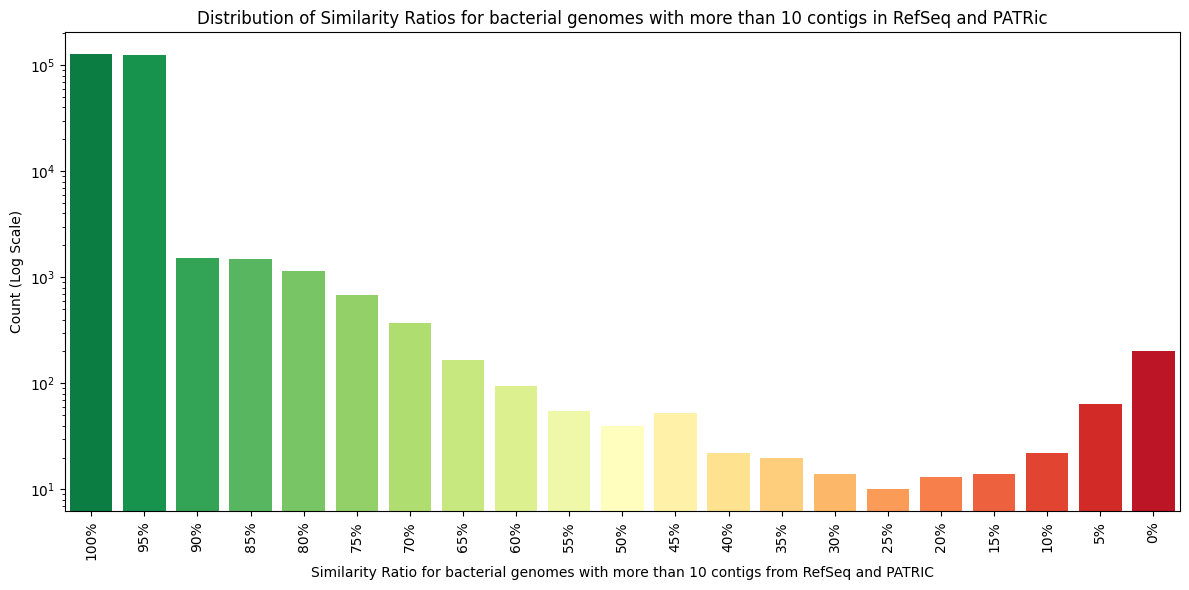

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of file paths
file_paths = [
    "results/output_file.csv",
    "results/2to2results.csv",
    "results/output_file_3.csv",
    "results/output_file_4.csv",
    "results/output_file_5.csv",
    "results/output_file_6.csv",
    "results/output_file_7.csv",
    "results/output_file_8.csv",
    "results/output_file_9.csv",
    "results/output_file_10.csv",

    "results/output_file_50k.csv",
    "results/output_file_50k_2.csv",
    "results/output_file_50k_3.csv",
    "results/output_file_50k_4.csv",
    "results/output_file_50k_5.csv"
]

# Define a function to categorize the ratios in 5% increments
def categorize_ratio_5(ratio):
    if ratio == 1.0:
        return '100%'
    for i in range(95, -1, -5):  # Categorizing from 95% to 0%
        if (i / 100) < ratio <= ((i + 5) / 100):
            return f'{i}%'
    return '0%'  # This will handle cases where ratio is exactly 0 or less

# Initialize an empty list to store data frames
df_list = []

# Loop through each file path
for file_path in file_paths:
    # Read the CSV
    df = pd.read_csv(file_path, dtype='str')

    # Convert columns to numeric
    df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
    df['n_of_5'] = pd.to_numeric(df['n_of_5'], errors='coerce')
    df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

    # Sum up n_of_1 and n_of_5
    df['n_total'] = df['n_of_1'].fillna(0) + df['n_of_5'].fillna(0)

    # Compute ratio
    df['ratio'] = df['n_total'] / df['subject_length']

    # Apply the categorization in 5% increments
    df['ratio_category'] = df['ratio'].apply(categorize_ratio_5)

    # Append the processed dataframe to the list
    df_list.append(df)

# Concatenate all data frames
all_df = pd.concat(df_list)

# Count occurrences per category
category_counts = all_df['ratio_category'].value_counts()

# Define a custom color palette
custom_palette = sns.color_palette("RdYlGn_r", n_colors=len(category_counts))

# Plot the cumulative counts with Seaborn countplot
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    x='ratio_category', 
    data=all_df, 
    order=[f'{i}%' for i in range(100, -1, -5)]
)

# Apply the custom palette to the bars
for p, color in zip(ax.patches, custom_palette):
    p.set_facecolor(color)

# Customize the plot
plt.xticks(rotation=90)
plt.xlabel('Similarity Ratio for bacterial genomes with more than 10 contigs from RefSeq and PATRIC')
plt.ylabel('Count (Log Scale)')
plt.title('Distribution of Similarity Ratios for bacterial genomes with more than 10 contigs in RefSeq and PATRic')
plt.yscale('log')
plt.tight_layout()
plt.show()


In [29]:
all_df[all_df['ratio_category']=='5%']


,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename,n_total,ratio,ratio_category
2976,53963,135577,SN11,135577.10,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,135577.10.fna,GCF_024584785.1_ASM2458478v1_genomic.fna,2834848,...,0,1738,39686,37277,0,518,135577_subject_array_1739120297.bin,186230,0.064211,5%
741,51652,1352,K189-3,1352.15661,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,1352.15661.fna,GCF_028335605.1_ASM2833560v1_genomic.fna,197358,...,0,7,1515,43842,0,51,1352_subject_array_1738943883.bin,278384,0.098189,5%
745,51676,1352,K75-1,1352.15662,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,1352.15662.fna,GCF_028335565.1_ASM2833556v1_genomic.fna,197358,...,0,27,1505,41831,0,34,1352_subject_array_1738943887.bin,279458,0.098493,5%
5069,269692,645,AS1,645.521,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,3,645.521.fna,GCF_028356375.1_ASM2835637v1_genomic.fna,75178,...,0,23,518,112903,0,41,645_subject_array_1738952124.bin,291027,0.060790,5%
881,83067,1590,ZW59,1590.3439,4,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,4,1590.3439.fna,GCF_027920405.1_ASM2792040v1_genomic.fna,128067,...,0,32,1159,26366,0,24,1590_subject_array_1739420483.bin,182338,0.056754,5%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21267,188959,541229,CT-43,541229.16,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,11,541229.16.fna,GCF_000193355.1_ASM19335v1_genomic.fna,281231,...,0,88,4947,38723,0,160,541229_subject_array_1743163191.bin,355245,0.057753,5%
27117,196274,562,401907,562.7692,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,95,562.7692.fna,GCF_001284645.1_8205_3_54_genomic.fna,391326,...,0,91,1740,7390,0,53,562_subject_array_1743184752.bin,406511,0.078692,5%
28648,197968,562,703273,562.7736,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,133,562.7736.fna,GCF_001285545.1_8205_3_44_genomic.fna,455856,...,0,106,2194,7153,0,58,562_subject_array_1743190767.bin,471483,0.096282,5%
39167,209969,562,KSC207,562.24606,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,562.24606.fna,GCF_002163955.1_ASM216395v1_genomic.fna,277790,...,0,0,17,3998,0,0,562_subject_array_1743231444.bin,284481,0.057073,5%


In [ ]:
all_df['ratio_category'].value_counts()

ratio_category
95%     118313
100%     85331
85%       1294
90%       1250
80%       1090
75%        659
70%        355
65%        164
0%         158
60%         92
55%         48
45%         42
5%          36
50%         35
40%         19
35%         14
10%         14
30%         13
15%         11
20%         10
25%         10
Name: count, dtype: int64

/var/folders/6d/tssj4xrn099f31yn8bqdpsgwsqb764/T/ipykernel_47838/1945803861.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


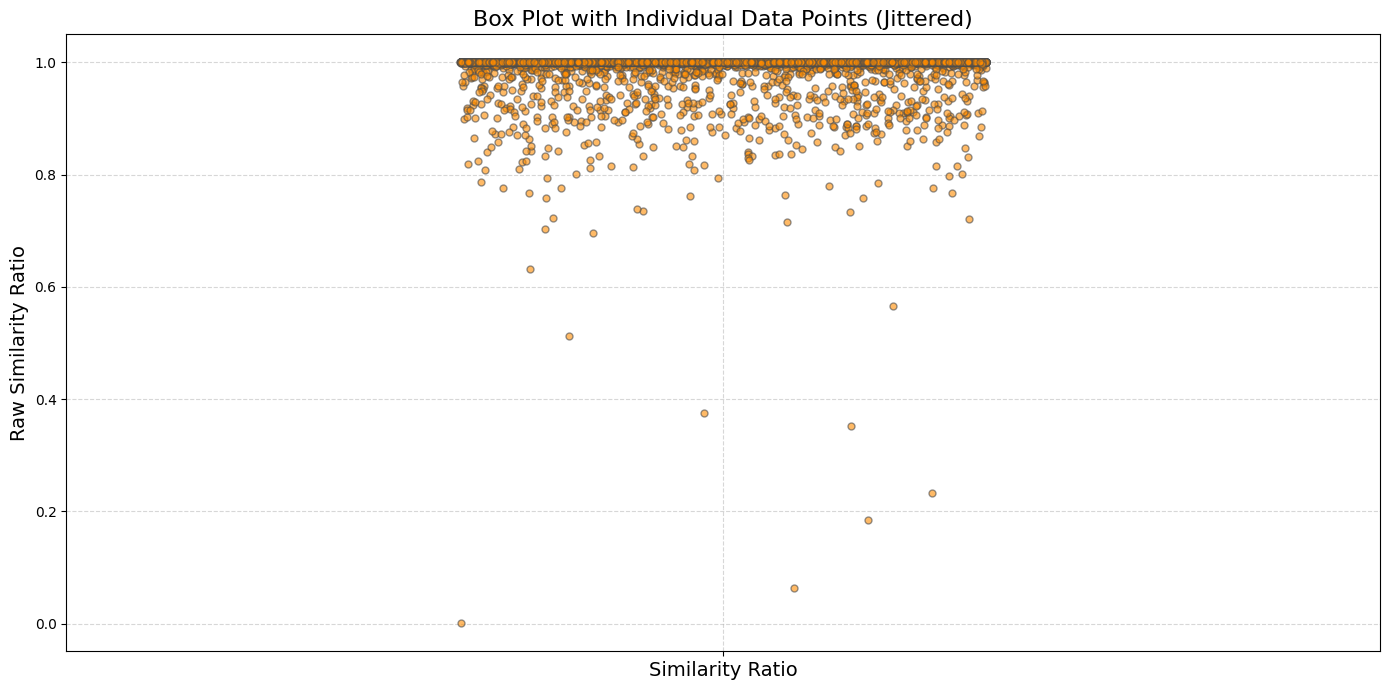

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# File path
file_paths = ["results/output_file.csv"]

# Load and preprocess data
df_list = []

for file_path in file_paths:
    df = pd.read_csv(file_path, dtype='str')
    df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
    df['n_of_5'] = pd.to_numeric(df['n_of_5'], errors='coerce')
    df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')
    df['n_total'] = df['n_of_1'].fillna(0) + df['n_of_5'].fillna(0)
    df['ratio'] = df['n_total'] / df['subject_length']
    df_list.append(df)

# Combine all data
all_df = pd.concat(df_list)

# ------------------------------
# 🎯 Improved Box Plot with Jittered Dots
# ------------------------------
plt.figure(figsize=(14, 7))

# Create the boxplot with improved aesthetics
sns.boxplot(
    x=np.ones_like(all_df['ratio']),  # All data in one group
    y=all_df['ratio'],
    palette="Blues",  # Using a soothing palette for boxplot
    showfliers=False,  # We'll handle dots separately
    width=0.3,  # Adjust box width for better spacing
    fliersize=0  # Hide outliers from the boxplot itself
)

# Overlay jittered individual dots (to represent raw data points)
sns.stripplot(
    x=np.ones_like(all_df['ratio']),
    y=all_df['ratio'],
    data=all_df,
    color='darkorange',  # Distinct color for dots
    size=5,  # Make the dots slightly larger
    jitter=0.2,  # Control the amount of jitter for clear separation
    alpha=0.6,  # Slight transparency to avoid overlapping visual clutter
    linewidth=1  # Ensure dots are outlined for clarity
)

# Customizing the plot
plt.xticks([0], ['Similarity Ratio'], fontsize=14)  # Label for x-axis (since there's one category)
plt.ylabel('Raw Similarity Ratio', fontsize=14)  # Label for y-axis
plt.title('Box Plot with Individual Data Points (Jittered)', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)  # Adding gridlines for better comparison
plt.tight_layout()

# Show the plot
plt.show()


/var/folders/6d/tssj4xrn099f31yn8bqdpsgwsqb764/T/ipykernel_47838/3019565395.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/6d/tssj4xrn099f31yn8bqdpsgwsqb764/T/ipykernel_47838/3019565395.py:72: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


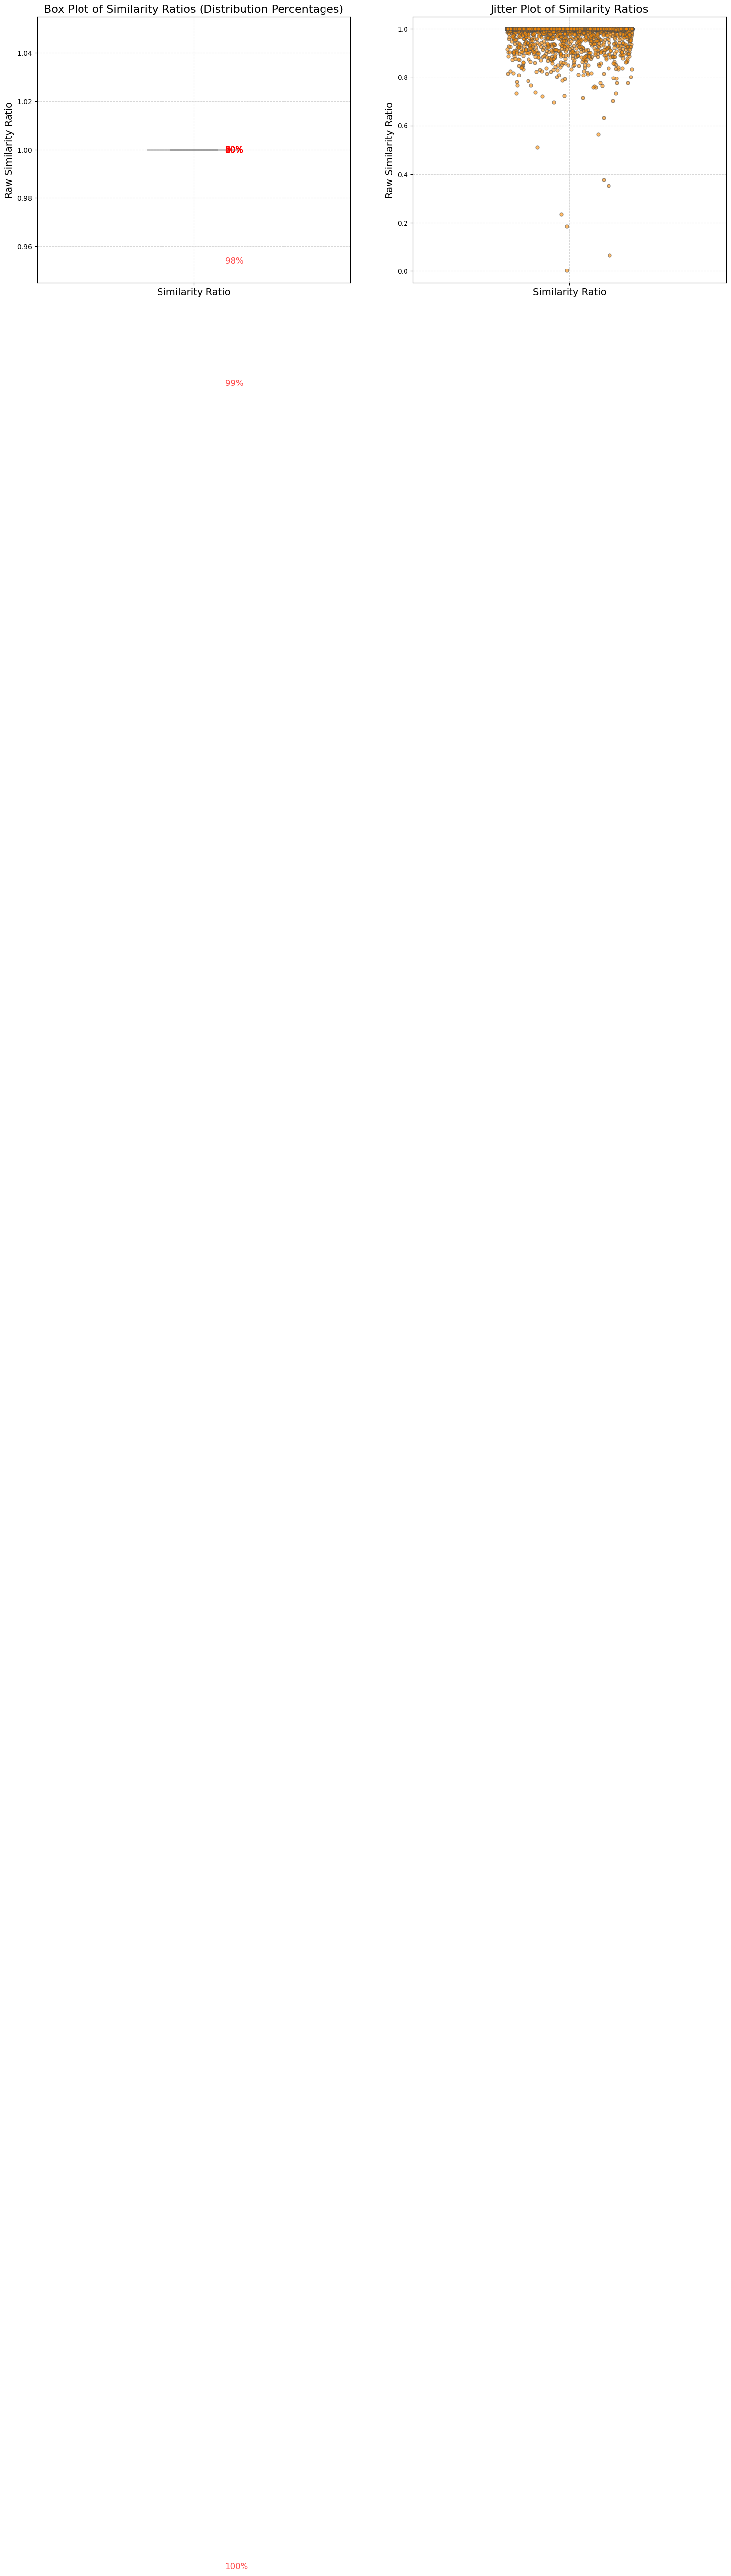

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# File path
file_paths = ["results/output_file.csv"]

# Load and preprocess data
df_list = []

for file_path in file_paths:
    df = pd.read_csv(file_path, dtype='str')
    df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
    df['n_of_5'] = pd.to_numeric(df['n_of_5'], errors='coerce')
    df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')
    df['n_total'] = df['n_of_1'].fillna(0) + df['n_of_5'].fillna(0)
    df['ratio'] = df['n_total'] / df['subject_length']
    df_list.append(df)

# Combine all data
all_df = pd.concat(df_list)

# ------------------------------
# 🎯 Create Subplots for Box Plot and Jitter Plot
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))  # 1 row, 2 columns for the plots

# 1. Box Plot (left plot)
sns.boxplot(
    x=np.ones_like(all_df['ratio']),  # All data in one group
    y=all_df['ratio'],
    palette="Blues",  # Using a soothing palette for boxplot
    showfliers=False,  # We'll handle dots separately
    width=0.3,  # Adjust box width for better spacing
    fliersize=0  # Hide outliers from the boxplot itself
    , ax=axes[0]  # Assign to the first subplot (left)
)

# Add distribution annotations for percentages (100%, 99%, 98%, etc.)
percentiles = [100, 99, 98, 90, 80, 70, 60, 50, 40, 30, 20, 10]
for p in percentiles:
    percentile_value = np.percentile(all_df['ratio'], 100 - p)
    axes[0].text(0.1, percentile_value, f'{p}%', ha='left', va='center', fontsize=12, color='red', alpha=0.7)

axes[0].set_xticks([0])
axes[0].set_xticklabels(['Similarity Ratio'], fontsize=14)  # Label for x-axis
axes[0].set_ylabel('Raw Similarity Ratio', fontsize=14)  # Label for y-axis
axes[0].set_title('Box Plot of Similarity Ratios (Distribution Percentages)', fontsize=16)
axes[0].grid(True, linestyle='--', alpha=0.5)  # Adding gridlines for better comparison

# 2. Jitter Plot (right plot)
sns.stripplot(
    x=np.ones_like(all_df['ratio']),
    y=all_df['ratio'],
    data=all_df,
    color='darkorange',  # Distinct color for dots
    size=5,  # Make the dots slightly larger
    jitter=0.2,  # Control the amount of jitter for clear separation
    alpha=0.6,  # Slight transparency to avoid overlapping visual clutter
    linewidth=1,  # Ensure dots are outlined for clarity
    ax=axes[1]  # Assign to the second subplot (right)
)

axes[1].set_xticks([0])
axes[1].set_xticklabels(['Similarity Ratio'], fontsize=14)  # Label for x-axis
axes[1].set_ylabel('Raw Similarity Ratio', fontsize=14)  # Label for y-axis
axes[1].set_title('Jitter Plot of Similarity Ratios', fontsize=16)
axes[1].grid(True, linestyle='--', alpha=0.5)  # Adding gridlines for better comparison

# Adjust layout to make sure labels/titles don't overlap
plt.tight_layout()

# Show combined plot
plt.show()


NaN values in Contigs and Entries columns:
Contigs    3
Entries    1
dtype: int64
Grouped and Sorted Data:
   Contig Group   Entries
0           1.0   21110.0
1           2.0    9084.0
2           3.0    5815.0
3           4.0    4073.0
4           5.0    3109.0
5           6.0    2334.0
6           7.0    1763.0
7           8.0    1424.0
8           9.0    1389.0
9          10.0    1345.0
10          10+  232858.0


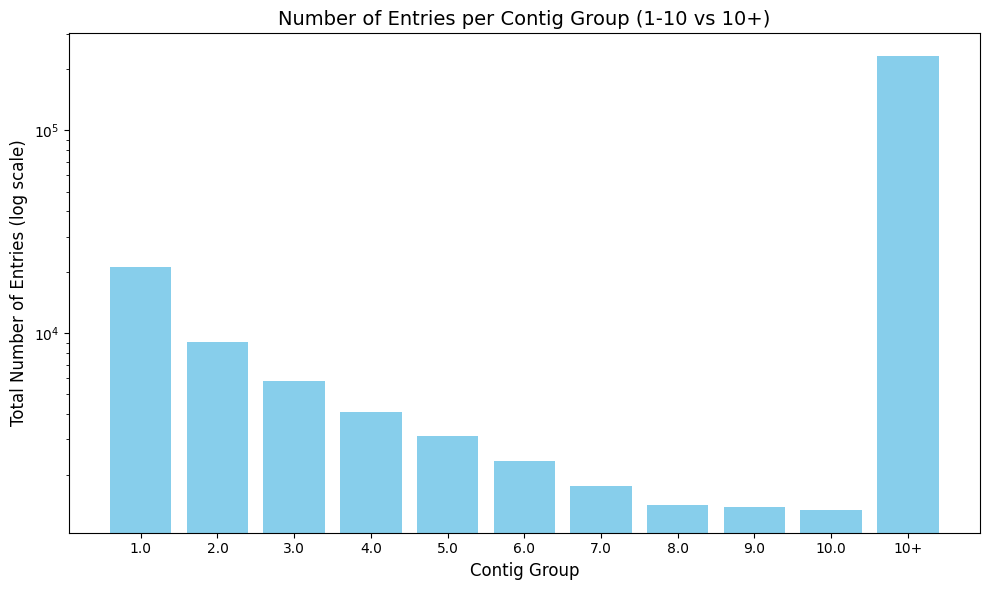

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Read the CSV file without headers (header=None), and manually set column names
df = pd.read_csv('summary.csv', header=None)

# Step 2: Assign column names: 'Contigs' and 'Entries'
df.columns = ['Contigs', 'Entries']

# Step 3: Convert 'Contigs' column to numeric, and force errors to NaN (invalid values will become NaN)
df['Contigs'] = pd.to_numeric(df['Contigs'], errors='coerce')

# Step 4: Convert 'Entries' column to numeric, and force errors to NaN
df['Entries'] = pd.to_numeric(df['Entries'], errors='coerce')

# Step 5: Check for any NaN values in 'Contigs' or 'Entries'
print("NaN values in Contigs and Entries columns:")
print(df.isna().sum())

# Step 6: Handle any rows with NaN values by dropping them or filling with a default value
df = df.dropna()  # Drop rows with NaN values (you can also fill NaNs with a value using df.fillna())

# Step 7: Define function to group contigs into categories: 1-10 and 10+
def group_contigs(contig):
    if contig <= 10:
        return str(contig)  # Show individual numbers 1, 2, ..., 10
    else:
        return '10+'  # Group all contigs > 10 as '10+'

# Step 8: Apply the grouping function to create a new column for the categories
df['Contig Group'] = df['Contigs'].apply(group_contigs)

# Step 9: Group by 'Contig Group' and sum the entries for each category
grouped_df = df.groupby('Contig Group').agg({'Entries': 'sum'}).reset_index()

# Step 10: Sort the grouped DataFrame by 'Entries' in descending order for the individual groups
grouped_df = grouped_df[grouped_df['Contig Group'] != '10+']  # Exclude '10+' temporarily
grouped_df = grouped_df.sort_values(by='Entries', ascending=False)  # Sort the remaining entries

# Step 11: Add the '10+' group back to the end
ten_plus_group = df[df['Contig Group'] == '10+'].groupby('Contig Group').agg({'Entries': 'sum'}).reset_index()
grouped_df = pd.concat([grouped_df, ten_plus_group], ignore_index=True)

# Step 12: Check the grouped and sorted data to ensure correct summing and sorting
print("Grouped and Sorted Data:")
print(grouped_df)

# Step 13: Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(grouped_df['Contig Group'], grouped_df['Entries'], color='skyblue')

# Step 14: Add title and labels
plt.title('Number of Entries per Contig Group (1-10 vs 10+)', fontsize=14)
plt.xlabel('Contig Group', fontsize=12)
plt.ylabel('Total Number of Entries (log scale)', fontsize=12)

# Step 15: Set the y-axis to log scale
plt.yscale('log')

# Step 16: Show the plot
plt.tight_layout()  # Ensures the plot layout is clean and avoids clipping
plt.show()


In [ ]:
df

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename,n_total,ratio,ratio_category
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,0,25,53,24129,0,0,1001534_subject_array_1739113446.bin,1892445,0.999782,95%
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,0,23,52,29,0,0,1001542_subject_array_1739113448.bin,1968517,0.999953,95%
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,0,0,0,0,0,0,1001585_subject_array_1739113452.bin,5434353,1.000000,100%
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,0,0,0,0,0,0,100226_subject_array_1739113458.bin,8667664,1.000000,100%
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,0,0,0,0,0,0,1002672_subject_array_1739113459.bin,1284727,1.000000,100%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20646,294973,99822,DB60705-15,99822.28,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.28.fna,GCF_009650275.1_ASM965027v1_genomic.fna,2190656,...,0,0,0,0,0,0,99822_subject_array_1739184665.bin,2190557,0.999955,95%
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,0,0,0,0,0,0,99822_subject_array_1739184667.bin,2201894,1.000000,100%
20648,294989,99822,STREP97-15,99822.29,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.29.fna,GCF_009650295.1_ASM965029v1_genomic.fna,2432570,...,0,0,0,0,0,0,99822_subject_array_1739184669.bin,2432471,0.999959,95%
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,0,0,0,0,0,0,999183_subject_array_1739184670.bin,1873758,1.000000,100%


In [ ]:
all_df['ratio_category'].value_counts()

ratio_category
100%    17655
95%      2592
90%       217
85%       113
80%        42
75%        15
70%         7
35%         2
65%         1
5%          1
55%         1
50%         1
0%          1
60%         1
20%         1
15%         1
Name: count, dtype: int64

In [ ]:
df

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename,n_total,ratio,ratio_category
0,22,1001240,DSM 21065,1001240.6,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1001240.6.fna,GCF_014200405.1_ASM1420040v1_genomic.fna,4531652,...,0,0,0,0,0,0,1001240_subject_array_1738727576.bin,4531652,1.000000,100%
1,27,1001582,LL3,1001582.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1001582.3.fna,GCF_000204275.1_ASM20427v1_genomic.fna,4001985,...,0,0,0,0,0,0,1001582_subject_array_1738727578.bin,4001985,1.000000,100%
2,40,1001705,1S-152-0914,1001705.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1001705.3.fna,GCF_000271285.1_ASM27128v1_genomic.fna,4897666,...,0,0,0,0,0,0,1001705_subject_array_1738727579.bin,4897666,1.000000,100%
3,91,100225,LK16-18,100225.4,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,100225.4.fna,GCF_003391095.1_ASM339109v1_genomic.fna,3631970,...,0,0,0,0,0,0,100225_subject_array_1738727581.bin,3631970,1.000000,100%
4,106,1002795,MB620,1002795.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1002795.3.fna,GCF_015732155.1_ASM1573215v1_genomic.fna,2691682,...,0,0,0,0,0,0,1002795_subject_array_1738727582.bin,2691682,1.000000,100%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29494,294244,985002,CFSA17SA054,985002.353,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10,985002.353.fna,GCF_021432415.1_ASM2143241v1_genomic.fna,2791501,...,0,0,1,0,0,0,985002_subject_array_1739893920.bin,2791051,0.999839,100%
29495,294615,992037,Hp A-20,992037.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10,992037.3.fna,GCF_000275285.1_ASM27528v1_genomic.fna,1674600,...,0,0,0,0,0,0,992037_subject_array_1739893921.bin,1674600,1.000000,100%
29496,295017,999423,F0473,999423.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10,999423.3.fna,GCF_000315545.1_Seleno_sp_F0473_V1_genomic.fna,2055819,...,0,0,0,1,0,0,999423_subject_array_1739893921.bin,2055825,0.994334,100%
29497,295037,999544,DSM 45548,999544.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10,999544.3.fna,GCF_000378825.1_ASM37882v1_genomic.fna,5096990,...,0,0,0,0,0,0,999544_subject_array_1739893923.bin,5097123,0.999869,100%


In [ ]:
# Filter the DataFrame for values between 90% and 95%
df_95_category = df[(df['ratio'] >= 0.95) & (df['ratio'] < 1)]

# Get the count of rows in this range
count_95_category = df_95_category.shape[0]

# Print the result
print(f"Count of values in the 95% category: {count_95_category}")


Count of values in the 95% category: 4860


In [ ]:
c = df['ratio']
df[c]


,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename,n_total,ratio,ratio_category


/var/folders/65/rjhnld5s4xv_rsh25jvbsq5r0000gp/T/ipykernel_2870/1245367230.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  below_70_df['ratio_category_1'] = below_70_df['ratio'].apply(categorize_ratio_1)


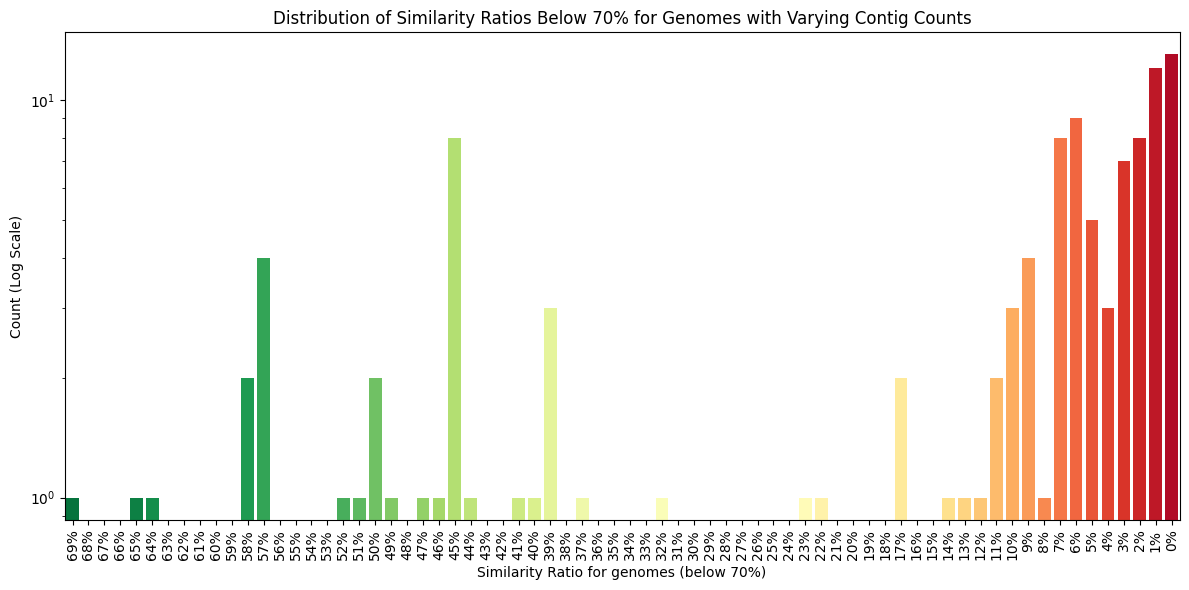

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of file paths
file_paths = [
    "results/2to2results.csv",
    "results/output_file_3.csv",
    "results/output_file_4.csv",
    "results/output_file_5.csv",
    "results/output_file_6.csv",
    "results/output_file_7.csv",
    "results/output_file_8.csv",
    "results/output_file_9.csv",
    "results/output_file_10.csv"
]

# Define a function to categorize the ratios in 1% increments for values below 70%
def categorize_ratio_1(ratio):
    for i in range(69, -1, -1):  # Categorizing from 69% to 0% in 1% increments
        if (i / 100) < ratio <= ((i + 1) / 100):
            return f'{i}%'
    return '0%'  # This will handle cases where ratio is exactly 0 or less

# Initialize an empty list to store data frames
df_list = []

# Loop through each file path
for file_path in file_paths:
    # Read the CSV
    df = pd.read_csv(file_path, dtype='str')

    # Convert columns to numeric
    df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
    df['n_of_5'] = pd.to_numeric(df['n_of_5'], errors='coerce')
    df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

    # Sum up n_of_1 and n_of_5
    df['n_total'] = df['n_of_1'].fillna(0) + df['n_of_5'].fillna(0)

    # Compute ratio
    df['ratio'] = df['n_total'] / df['subject_length']

    # Apply the categorization in 5% increments
    df['ratio_category'] = df['ratio'].apply(categorize_ratio_5)

    # Append the processed dataframe to the list
    df_list.append(df)

# Concatenate all data frames
all_df = pd.concat(df_list)

# Filter data for ratios below 70%
below_70_df = all_df[all_df['ratio'] < 0.7]

# Apply 1% categorization for the filtered data
below_70_df['ratio_category_1'] = below_70_df['ratio'].apply(categorize_ratio_1)

# Count occurrences per category for ratios below 70%
category_counts_below_70 = below_70_df['ratio_category_1'].value_counts()

# Define a custom color palette
custom_palette = sns.color_palette("RdYlGn_r", n_colors=len(category_counts_below_70))

# Plot the distribution for ratios below 70% with 1% increments
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    x='ratio_category_1', 
    data=below_70_df, 
    order=[f'{i}%' for i in range(69, -1, -1)]
)

# Apply the custom palette to the bars
for p, color in zip(ax.patches, custom_palette):
    p.set_facecolor(color)

# Customize the plot
plt.xticks(rotation=90)
plt.xlabel('Similarity Ratio for genomes (below 70%)')
plt.ylabel('Count (Log Scale)')
plt.title('Distribution of Similarity Ratios Below 70% for Genomes with Varying Contig Counts')
plt.yscale('log')
plt.tight_layout()
plt.show()
